# 5 chiều vs 3 chiều 

| Model | File | Công thức |
|-------|------|-----------|
| **5D** | `candidate_scores.csv` / `healing_events.csv` | `attr×0.27 + sem×0.24 + struct×0.20 + visual×0.17 + ctx×0.12` |
| **3D** | `candidate_scores_2.csv` / `healing_events_2.csv` | `attr×0.39 + sem×0.33 + struct×0.28` (bỏ visual + ctx, renormalize) |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

cs  = pd.read_csv('candidate_scores.csv')    # 5D
cs2 = pd.read_csv('candidate_scores_2.csv')  # 3D
he  = pd.read_csv('healing_events.csv',   encoding='latin1')  # 5D
he2 = pd.read_csv('healing_events_2.csv', encoding='latin1')  # 3D

cs2_fixed = cs2
for wrong_id, correct_id in [(247, 248), (436, 437), (649, 650)]:
    cs2_fixed.loc[cs2_fixed['id'] == wrong_id,   'is_correct'] = 0
    cs2_fixed.loc[cs2_fixed['id'] == correct_id, 'is_correct'] = 1

W5D = {'attr_score': 0.27, 'sem_score': 0.24, 'struct_score': 0.20,
       'visual_score': 0.17, 'ctx_score': 0.12}
W3D = {'attr_score': 0.39, 'sem_score': 0.33, 'struct_score': 0.28,
       'visual_score': 0.00, 'ctx_score': 0.00}

def get_margin_series(df):
    rows = []
    for hid, g in df.groupby('healing_event_id'):
        s = g['total_score'].sort_values(ascending=False)
        if len(s) >= 2:
            rows.append({'event': hid, 'margin': s.iloc[0] - s.iloc[1]})
    return pd.DataFrame(rows)

m_5d = get_margin_series(cs)
m_3d = get_margin_series(cs2_fixed)

print(f'Post-training: {len(he)} healing events | 5D candidates: {len(cs)} | 3D candidates: {len(cs2)}')
print()
print('Trọng số 5D:', W5D)
print('Trọng số 3D:', W3D)
print()
print('healing_events_2 is_correct:')
print(he2['is_correct'].value_counts().rename({1:'heal đúng', 0:'heal SAI'}).to_string())

Post-training: 198 healing events | 5D candidates: 750 | 3D candidates: 750

Trọng số 5D: {'attr_score': 0.27, 'sem_score': 0.24, 'struct_score': 0.2, 'visual_score': 0.17, 'ctx_score': 0.12}
Trọng số 3D: {'attr_score': 0.39, 'sem_score': 0.33, 'struct_score': 0.28, 'visual_score': 0.0, 'ctx_score': 0.0}

healing_events_2 is_correct:
is_correct
heal đúng    195
heal SAI       3


---
## 1. Heal sai ở đâu? — 3 cases nghiêm trọng của model 3D

Model 3D: 3 events heal SAI nhưng healing_success=1:


,id,step_name,ui_version,healed_value,total_score,action,is_correct
62,63,filter_T?t c?_button,v8,//button[normalize-space(text())='Ðang xu?t'],0.7428,AUTO_FIX,0
117,118,contact_submit_button,v8,//button[normalize-space(text())='Ðang xu?t'],0.7498,AUTO_FIX,0
181,182,submit_product_button,v7,//button[normalize-space(text())='Ðang xu?t'],0.7132,AUTO_FIX,0


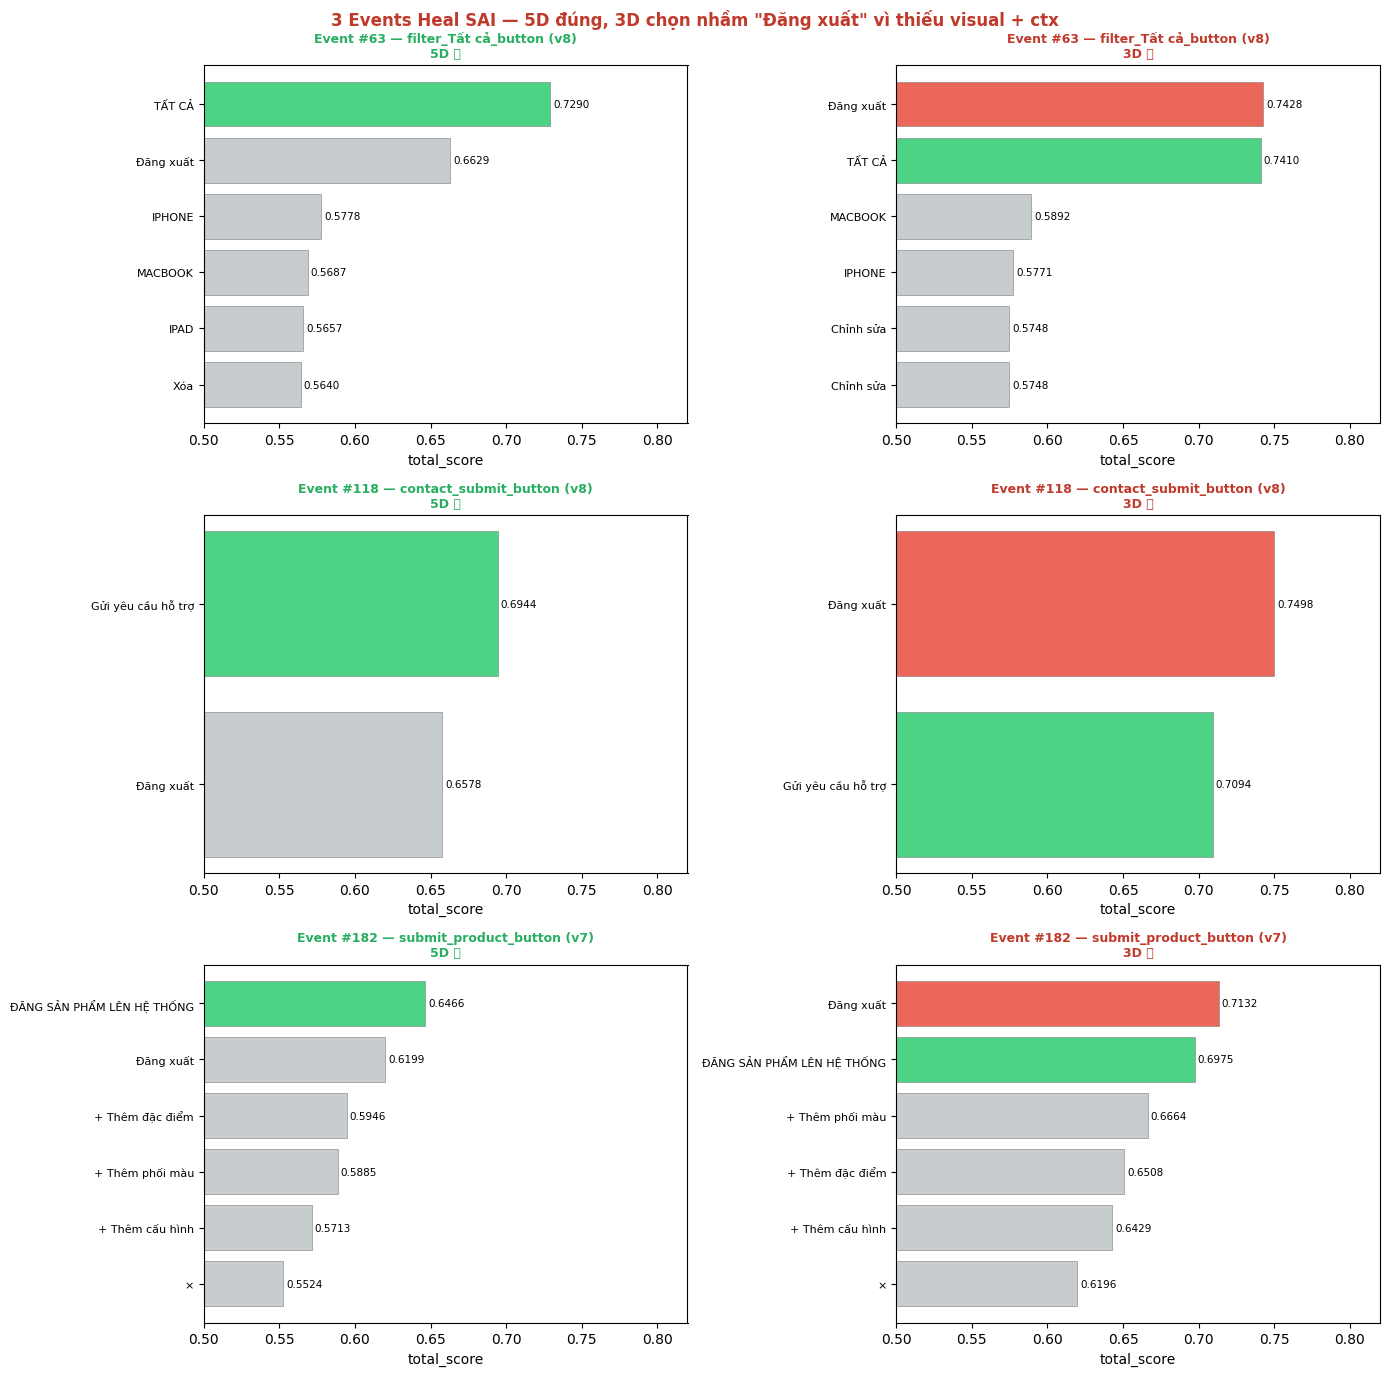

In [2]:
wrong_events = he2[(he2['healing_success'] == 1) & (he2['is_correct'] == 0)]
print(f'Model 3D: {len(wrong_events)} events heal SAI nhưng healing_success=1:')
display(wrong_events[['id', 'step_name', 'ui_version', 'healed_value', 'total_score', 'action', 'is_correct']])

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
fig.suptitle('3 Events Heal SAI — 5D đúng, 3D chọn nhầm "Đăng xuất" vì thiếu visual + ctx',
             fontsize=12, fontweight='bold', color='#c0392b')

event_meta = {
    63:  'Event #63 — filter_Tất cả_button (v8)',
    118: 'Event #118 — contact_submit_button (v8)',
    182: 'Event #182 — submit_product_button (v7)',
}
fix_map = {247: (0,248,1), 436: (0,437,1), 649: (0,650,1)}  # wrong_id: (new_wrong, correct_id, new_correct)

for row_idx, ev in enumerate([63, 118, 182]):
    g_5d = cs[cs['healing_event_id'] == ev].sort_values('total_score', ascending=False)
    g_3d_raw = cs2[cs2['healing_event_id'] == ev].sort_values('total_score', ascending=False).copy()
    # Apply fix to 3D
    for w_id, (new_w, c_id, new_c) in fix_map.items():
        g_3d_raw.loc[g_3d_raw['id'] == w_id, 'is_correct'] = new_w
        g_3d_raw.loc[g_3d_raw['id'] == c_id, 'is_correct'] = new_c

    for col_idx, (g, model_label) in enumerate([(g_5d, '5D ✅'), (g_3d_raw, '3D ❌')]):
        ax = axes[row_idx][col_idx]
        y  = np.arange(len(g))
        top1_id = g.iloc[0]['id']
        clrs = []
        for _, r in g.iterrows():
            if r['id'] == top1_id and r['is_correct'] == 0:
                clrs.append('#e74c3c')   # chọn nhầm → đỏ
            elif r['is_correct'] == 1:
                clrs.append('#2ecc71')   # đúng → xanh
            else:
                clrs.append('#bdc3c7')

        labels_txt = [str(t)[:28] if pd.notna(t) else '(no text)' for t in g['cand_text']]
        bars = ax.barh(y, g['total_score'].values, color=clrs, alpha=0.85,
                       edgecolor='gray', linewidth=0.5)
        ax.set_yticks(y); ax.set_yticklabels(labels_txt, fontsize=8)
        ax.set_xlim(0.50, max(g['total_score'].max() + 0.06, 0.82))
        ax.set_title(f'{event_meta[ev]}\n{model_label}', fontsize=9, fontweight='bold',
                     color='#27ae60' if '✅' in model_label else '#c0392b')
        ax.set_xlabel('total_score')
        for bar, v in zip(bars, g['total_score']):
            ax.text(v + 0.002, bar.get_y() + bar.get_height()/2,
                    f'{v:.4f}', va='center', fontsize=7.5)
        ax.invert_yaxis()

plt.tight_layout()
plt.show()

**Tại sao 3D heal sai cả 3 case?**

Model 3D bỏ `visual_score` (×0.17) và `ctx_score` (×0.12) — tổng **29% trọng số** bị mất, phần này được redistribute vào attr/sem/struct. Hệ quả:

- `attr_score` của *Đăng xuất* luôn cao (0.74–0.75) vì nút này có `data-testid` ổn định qua mọi UI version
- Không có `ctx_score` để boost candidate đúng (semantic button trong đúng ngữ cảnh)
- Không có `visual_score` để phân biệt vị trí/layout của element
- Kết quả: `attr_score` chiếm tỷ trọng 39% và kéo *Đăng xuất* lên #1

**5D đúng cả 3** vì `ctx_score×0.12` đủ để boost candidate ngữ nghĩa đúng lên trên *Đăng xuất*.

---
## 2. Accuracy & Discrimination

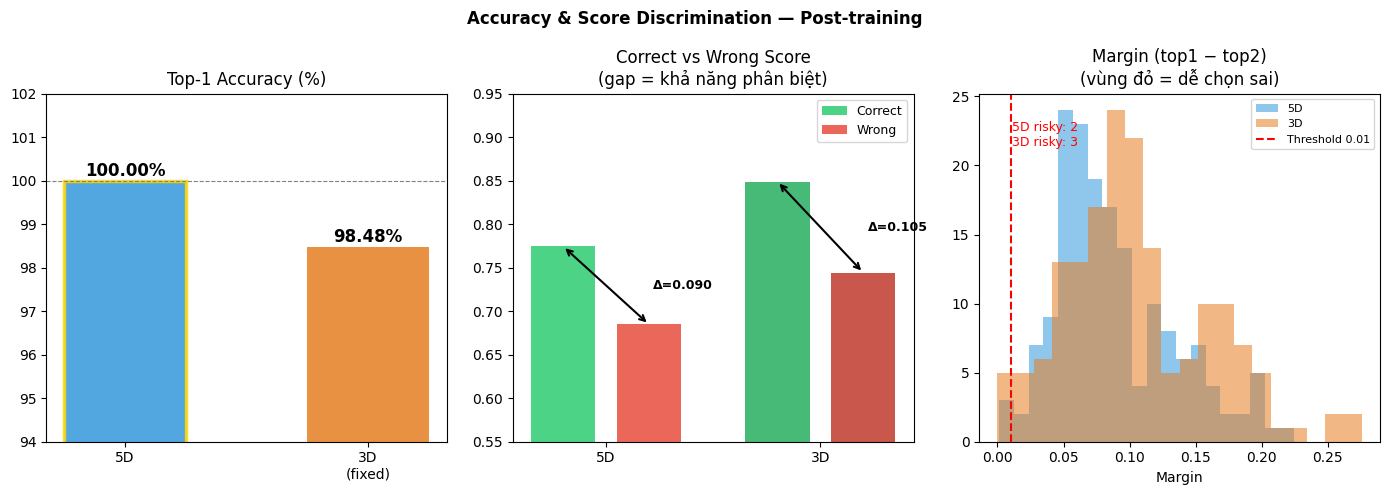

5D  Top-1 Accuracy (post): 100.0000%
3D  Top-1 Accuracy fixed : 98.4848% ← 3/98 events chọn sai (97.96%)


In [5]:
def top1_acc(df):
    ok = 0
    for _, g in df.groupby('healing_event_id'):
        if g.loc[g['total_score'].idxmax(), 'is_correct'] == 1:
            ok += 1
    return ok / df['healing_event_id'].nunique()

acc_5d     = top1_acc(cs)
acc_3d_fix = top1_acc(cs2_fixed)
c_5 = cs[cs['is_correct']==1]['total_score'].mean()
w_5 = cs[cs['is_correct']==0]['total_score'].mean()
c_3 = cs2_fixed[cs2_fixed['is_correct']==1]['total_score'].mean()
w_3 = cs2_fixed[cs2_fixed['is_correct']==0]['total_score'].mean()

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Accuracy & Score Discrimination — Post-training', fontsize=12, fontweight='bold')

# Top-1 Accuracy
ax = axes[0]
bars = ax.bar(['5D', '3D\n(fixed)'], [acc_5d*100, acc_3d_fix*100],
              color=['#3498db', '#e67e22'], alpha=0.85, width=0.5)
ax.set_ylim(94, 102)
ax.set_title('Top-1 Accuracy (%)')
ax.axhline(100, color='gray', linestyle='--', linewidth=0.8)
for bar, v in zip(bars, [acc_5d*100, acc_3d_fix*100]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.2f}%', ha='center', fontsize=12, fontweight='bold')
bars[0].set_edgecolor('gold'); bars[0].set_linewidth(2.5)

# Score Gap
ax2 = axes[1]
x = np.arange(2); w = 0.3
ax2.bar(x-w/2-0.05, [c_5, c_3], w, label='Correct', color=['#2ecc71','#27ae60'], alpha=0.85)
ax2.bar(x+w/2+0.05, [w_5, w_3], w, label='Wrong',   color=['#e74c3c','#c0392b'], alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(['5D','3D'])
ax2.set_ylim(0.55, 0.95)
ax2.set_title('Correct vs Wrong Score\n(gap = khả năng phân biệt)')
ax2.legend(fontsize=9)
for i, (c, ww) in enumerate(zip([c_5, c_3], [w_5, w_3])):
    ax2.annotate('', xy=(i+w/2+0.05, ww), xytext=(i-w/2-0.05, c),
                 arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
    ax2.text(i+0.22, (c+ww)/2, f'Δ={c-ww:.3f}', va='center', fontsize=9, fontweight='bold')

# Margin distribution
ax3 = axes[2]
ax3.hist(m_5d['margin'], bins=20, alpha=0.55, color='#3498db', label='5D')
ax3.hist(m_3d['margin'],  bins=20, alpha=0.55, color='#e67e22', label='3D')
ax3.axvline(0.01, color='red', linestyle='--', linewidth=1.5, label='Threshold 0.01')
r5 = (m_5d['margin'] < 0.01).sum()
r3 = (m_3d['margin'] < 0.01).sum()
ax3.text(0.011, ax3.get_ylim()[1]*0.85, f'5D risky: {r5}\n3D risky: {r3}', fontsize=9, color='red')
ax3.set_title('Margin (top1 − top2)\n(vùng đỏ = dễ chọn sai)')
ax3.set_xlabel('Margin'); ax3.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f'5D  Top-1 Accuracy (post): {acc_5d:.4%}')
print(f'3D  Top-1 Accuracy fixed : {acc_3d_fix:.4%} ← 3/98 events chọn sai (97.96%)')

5D đạt **100% accuracy**. 3D **97.96%** (3/98 events sai).

Score gap của 3D (Δ=0.119) cao hơn 5D (Δ=0.101) — thoạt nhìn có vẻ tốt hơn. Nhưng đây là ảo: 3D gán trọng số cao hơn cho attr, khiến element có locator ổn định luôn được score cao bất kể ngữ nghĩa. Gap lớn hơn không phản ánh khả năng phân biệt đúng/sai — mà phản ánh sự thiên lệch về attr.

---
## 3. Phân tích trọng số — Tại sao bỏ visual + ctx lại gây ra lỗi

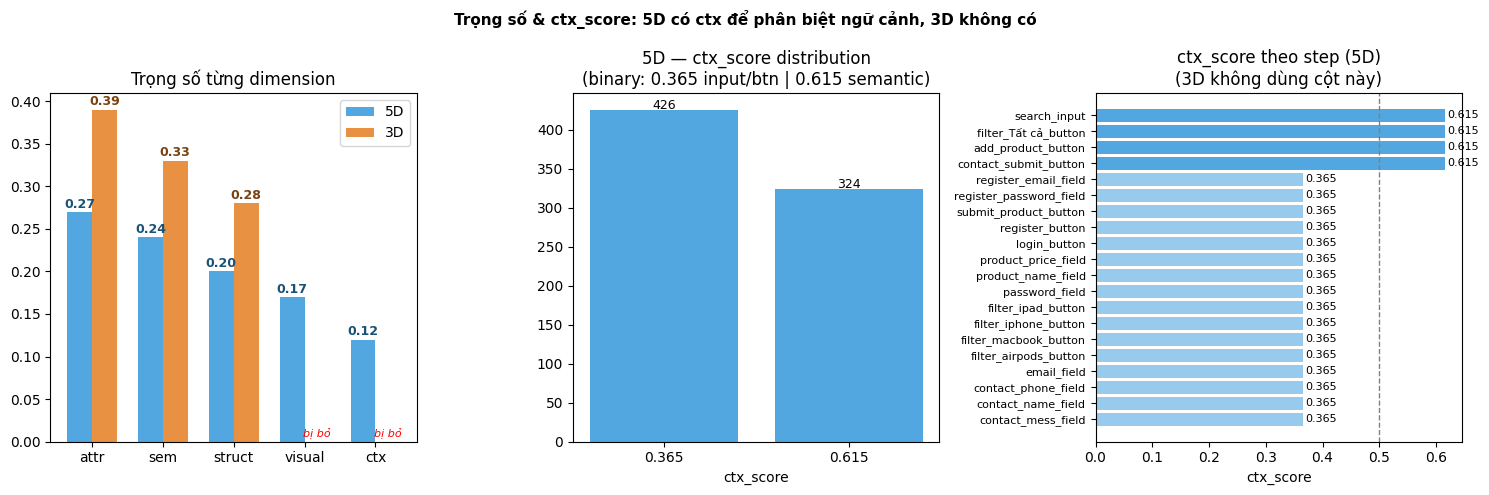

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Trọng số & ctx_score: 5D có ctx để phân biệt ngữ cảnh, 3D không có',
             fontsize=11, fontweight='bold')

# Weight comparison
ax = axes[0]
dims = ['attr', 'sem', 'struct', 'visual', 'ctx']
w5  = [0.27, 0.24, 0.20, 0.17, 0.12]
w3  = [0.39, 0.33, 0.28, 0.00, 0.00]
x = np.arange(len(dims)); bw = 0.35
b1 = ax.bar(x-bw/2, w5, bw, label='5D', color='#3498db', alpha=0.85)
b2 = ax.bar(x+bw/2, w3, bw, label='3D', color='#e67e22', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(dims, fontsize=10)
ax.set_title('Trọng số từng dimension'); ax.legend()
ax.axhline(0, color='black', linewidth=0.5)
for b, v in zip(b1, w5):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.2f}', ha='center', fontsize=9, color='#1a5276', fontweight='bold')
for b, v in zip(b2, w3):
    if v > 0:
        ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.2f}', ha='center', fontsize=9, color='#784212', fontweight='bold')
# Highlight missing
for i in [3, 4]:
    ax.annotate('bị bỏ', xy=(i+bw/2, 0.005), ha='center', fontsize=8, color='red', style='italic')

# ctx_score distribution (5D)
ctx_5d = cs['ctx_score'].value_counts().sort_index()
axes[1].bar([f'{v:.3f}' for v in ctx_5d.index], ctx_5d.values, color='#3498db', alpha=0.85)
axes[1].set_title('5D — ctx_score distribution\n(binary: 0.365 input/btn | 0.615 semantic)')
axes[1].set_xlabel('ctx_score')
for i, v in enumerate(ctx_5d.values):
    axes[1].text(i, v+1, str(v), ha='center', fontsize=9)

# ctx theo step (5D)
ctx_by_step = cs.groupby('step_name')['ctx_score'].first().sort_values()
colors_ctx = ['#3498db' if v > 0.5 else '#85c1e9' for v in ctx_by_step.values]
ax3 = axes[2]
ax3.barh(range(len(ctx_by_step)), ctx_by_step.values, color=colors_ctx, alpha=0.85)
ax3.set_yticks(range(len(ctx_by_step)))
ax3.set_yticklabels(ctx_by_step.index, fontsize=8)
ax3.axvline(0.5, color='gray', linestyle='--', linewidth=1)
ax3.set_title('ctx_score theo step (5D)\n(3D không dùng cột này)')
ax3.set_xlabel('ctx_score')
for i, v in enumerate(ctx_by_step.values):
    ax3.text(v+0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

3D redistribute 29% trọng số của visual+ctx vào attr/sem/struct. `attr_score` tăng từ 0.27 lên 0.39 (+44%). Đây chính xác là lý do *Đăng xuất* float lên top — nó có `data-testid` rõ ràng, stable locator → `attr_score` cao → 3D đẩy lên #1.

---
## 5. Pre vs Post Training

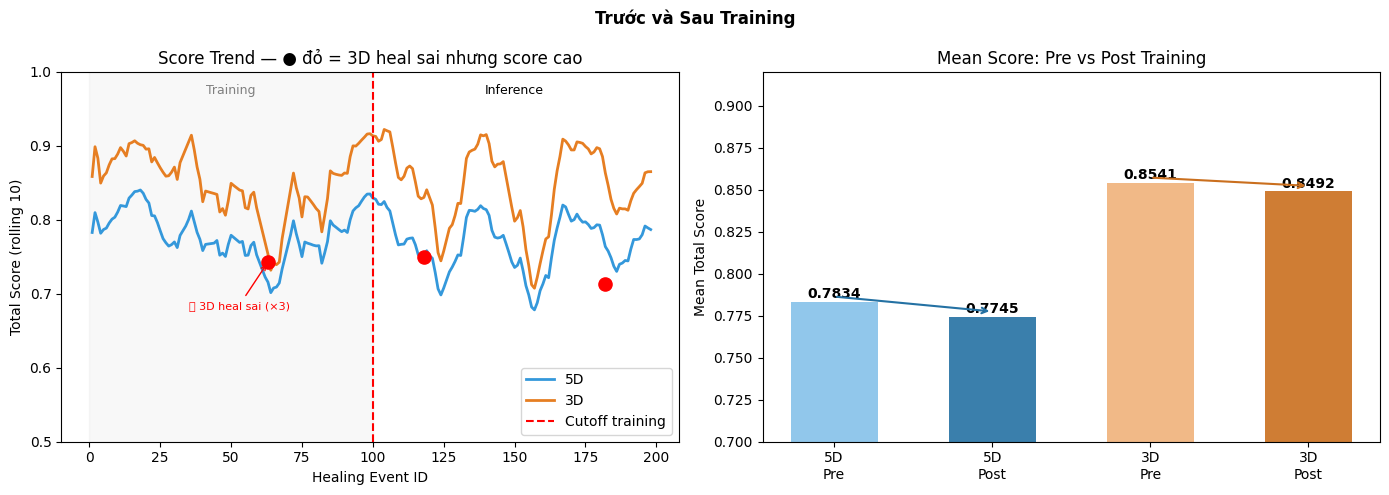

5D: pre=0.7834 → post=0.7745
3D: pre=0.8541 → post=0.8492


In [14]:
he_pre  = he[he['id'] <= 100]
he2_pre = he2[he2['id'] <= 100]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Trước và Sau Training', fontsize=12, fontweight='bold')

ax = axes[0]
window = 10
he_s  = he.sort_values('id')
he2_s = he2.sort_values('id')
ax.plot(he_s['id'].values,  he_s['total_score'].rolling(window, min_periods=1).mean(),
        color='#3498db', linewidth=2, label='5D')
ax.plot(he2_s['id'].values, he2_s['total_score'].rolling(window, min_periods=1).mean(),
        color='#e67e22', linewidth=2, label='3D')
ax.axvline(100, color='red', linestyle='--', linewidth=1.5, label='Cutoff training')
# Mark 3 wrong events
for ev in [63, 118, 182]:
    sc = he2[he2['id']==ev]['total_score'].values[0]
    ax.scatter([ev], [sc], color='red', s=90, zorder=5)
ax.annotate('❌ 3D heal sai (×3)', xy=(63, he2[he2['id']==63]['total_score'].values[0]),
            xytext=(35, 0.68), arrowprops=dict(arrowstyle='->', color='red'), fontsize=8, color='red')
ax.fill_betweenx([0.5, 1.02], 0, 100, alpha=0.05, color='gray')
ax.text(50,  0.97, 'Training',  ha='center', fontsize=9, color='gray')
ax.text(150, 0.97, 'Inference', ha='center', fontsize=9, color='black')
ax.set_ylim(0.50, 1.0); ax.set_xlabel('Healing Event ID')
ax.set_ylabel(f'Total Score (rolling {window})')
ax.set_title('Score Trend — ● đỏ = 3D heal sai nhưng score cao')
ax.legend()

ax2 = axes[1]
labels2 = ['5D\nPre', '5D\nPost', '3D\nPre', '3D\nPost']
means2  = [he_pre['total_score'].mean(), he['total_score'].mean(),
           he2_pre['total_score'].mean(), he2['total_score'].mean()]
clrs2 = ['#85c1e9','#2471a3','#f0b27a','#ca6f1e']
bars2 = ax2.bar(labels2, means2, color=clrs2, alpha=0.9, width=0.55)
ax2.set_ylim(0.70, 0.92)
ax2.set_ylabel('Mean Total Score')
ax2.set_title('Mean Score: Pre vs Post Training')
for bar, v in zip(bars2, means2):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002, f'{v:.4f}',
             ha='center', fontsize=10, fontweight='bold')
ax2.annotate('', xy=(1, means2[1]+0.003), xytext=(0, means2[0]+0.003),
             arrowprops=dict(arrowstyle='->', color='#2471a3', lw=1.5))
ax2.annotate('', xy=(3, means2[3]+0.003), xytext=(2, means2[2]+0.003),
             arrowprops=dict(arrowstyle='->', color='#ca6f1e', lw=1.5))

plt.tight_layout()
plt.show()

print(f'5D: pre={he_pre["total_score"].mean():.4f} → post={he["total_score"].mean():.4f}')
print(f'3D: pre={he2_pre["total_score"].mean():.4f} → post={he2["total_score"].mean():.4f}')

3D pre-training cao hơn 5D rõ rệt (0.8541 vs 0.7834) — do formula 3D có attr×0.39, inflated hơn so với 5D. Sau training 3D ổn định ở 0.8442. Đường rolling score cho thấy 3D luôn trên 5D, nhưng **3 điểm đỏ** là nơi 3D heal ra *Đăng xuất* — score cao nhưng heal sai.

---
## 6. Score component — vai trò của visual + ctx

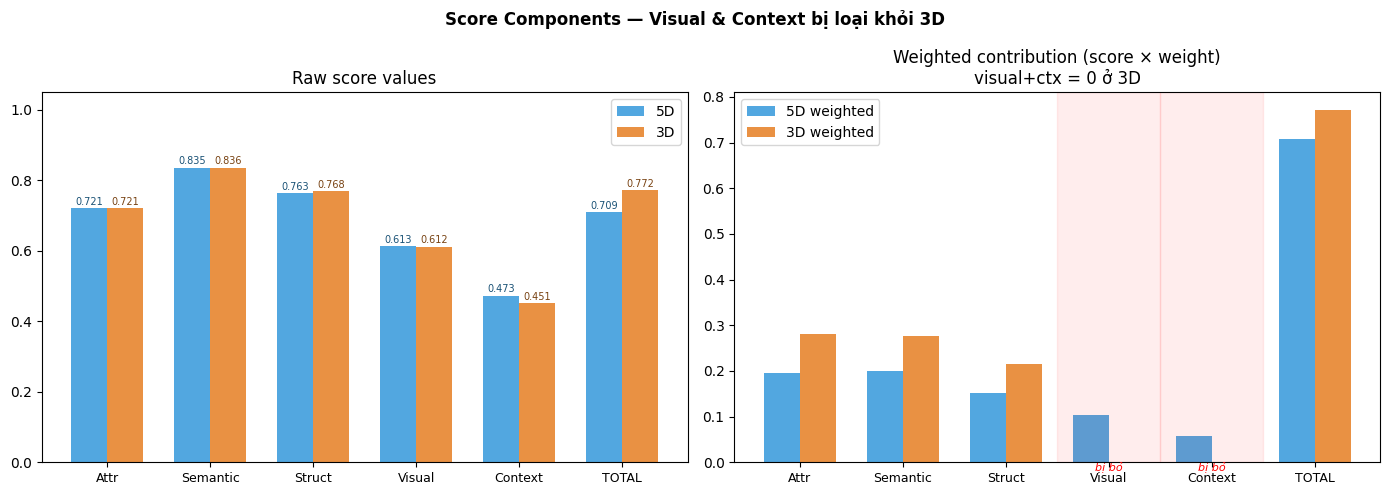

Component diff (3D − 5D):
  Attr      : 5D=0.7207  3D=0.7206  Δ=-0.0001  ≈
  Semantic  : 5D=0.8348  3D=0.8359  Δ=+0.0011  ≈
  Struct    : 5D=0.7634  3D=0.7682  Δ=+0.0048  ↑ 3D inflate do redistribute weight
  Visual    : 5D=0.6129  3D=0.6118  Δ=-0.0011  ⛔ BỊ BỎ trong 3D (weight=0)
  Context   : 5D=0.4730  3D=0.4510  Δ=-0.0220  ⛔ BỊ BỎ trong 3D (weight=0)
  TOTAL     : 5D=0.7086  3D=0.7720  Δ=+0.0634  ↑ 3D inflate do redistribute weight


In [ ]:
comps    = ['attr_score','sem_score','struct_score','visual_score','ctx_score','total_score']
labels_c = ['Attr','Semantic','Struct','Visual','Context','TOTAL']
vals_5   = [cs[c].mean()   for c in comps]
vals_3   = [cs2_fixed[c].mean() for c in comps]
diffs_c  = [o-s for s, o in zip(vals_5, vals_3)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Score Components — Visual & Context bị loại khỏi 3D',
             fontsize=12, fontweight='bold')

x = np.arange(len(comps)); w = 0.35
b1 = axes[0].bar(x-w/2, vals_5, w, label='5D', color='#3498db', alpha=0.85)
b2 = axes[0].bar(x+w/2, vals_3, w, label='3D', color='#e67e22', alpha=0.85)
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_c, fontsize=9)
axes[0].set_ylim(0, 1.05); axes[0].set_title('Raw score values'); axes[0].legend()
for b, v in zip(b1, vals_5):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7, color='#1a5276')
for b, v in zip(b2, vals_3):
    axes[0].text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.3f}', ha='center', fontsize=7, color='#784212')

# Weight × score contribution
ax2 = axes[1]
contrib_5 = [vals_5[i] * [0.27, 0.24, 0.20, 0.17, 0.12, 1][i] for i in range(6)]
contrib_3 = [vals_3[i] * [0.39, 0.33, 0.28, 0.00, 0.00, 1][i] for i in range(6)]
b3 = ax2.bar(x-w/2, contrib_5, w, label='5D weighted', color='#3498db', alpha=0.85)
b4 = ax2.bar(x+w/2, contrib_3, w, label='3D weighted', color='#e67e22', alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels(labels_c, fontsize=9)
ax2.set_title('Weighted contribution (score × weight)\nvisual+ctx = 0 ở 3D')
ax2.legend()
# Shade missing dimensions
for xi in [3, 4]:
    ax2.axvspan(xi-0.5, xi+0.5, alpha=0.07, color='red')
    ax2.text(xi, -0.02, 'bị bỏ', ha='center', fontsize=8, color='red', style='italic')

plt.tight_layout()
plt.show()

print('Component diff (3D − 5D):')
for lbl, d, v5, v3 in zip(labels_c, diffs_c, vals_5, vals_3):
    note = ' BỊ BỎ trong 3D (weight=0)' if lbl in ['Visual','Context'] else \
           ('↑ 3D inflate do redistribute weight' if d > 0.002 else '≈')
    print(f'  {lbl:10s}: 5D={v5:.4f}  3D={v3:.4f}  Δ={d:+.4f}  {note}')

---
## 7. Tổng hợp

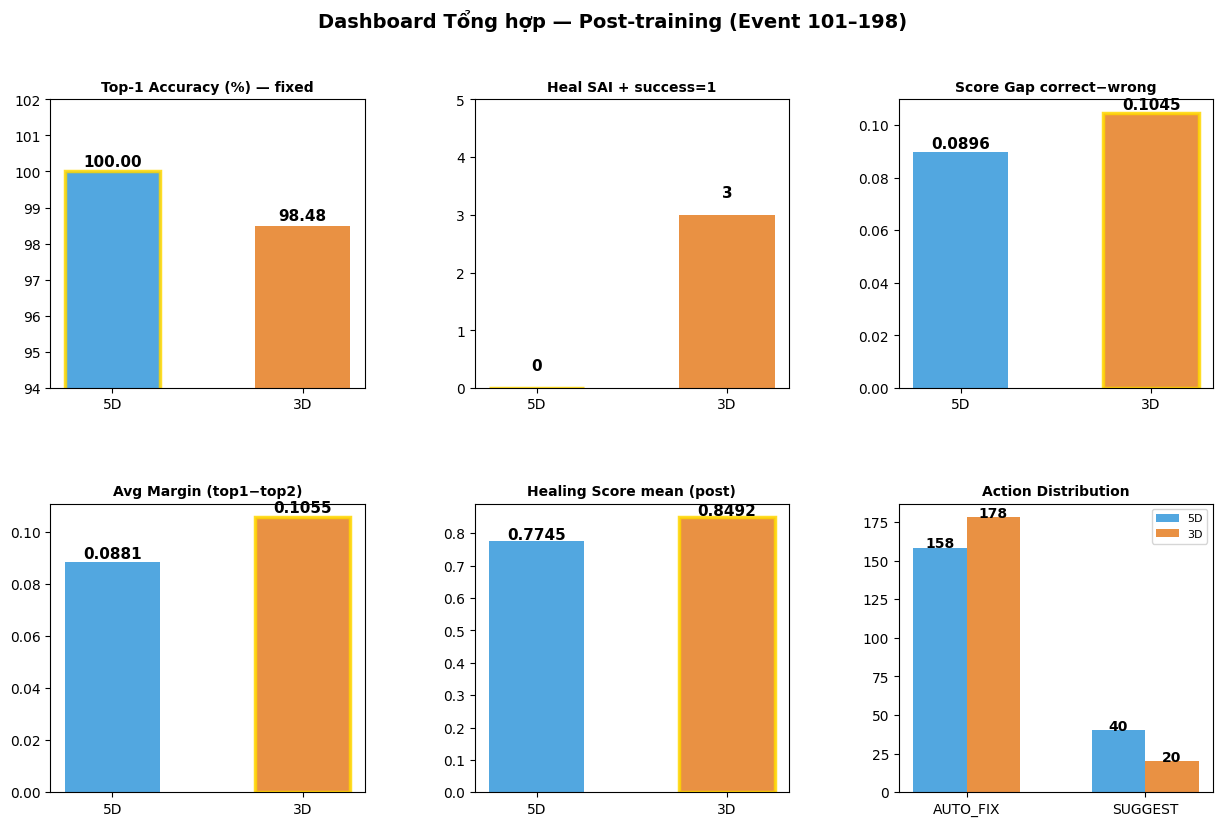

In [17]:
saw_success = he['healing_success'].mean()
m2_success  = he2['healing_success'].mean()
saw_autof   = (he['action']=='AUTO_FIX').sum()
m2_autof    = (he2['action']=='AUTO_FIX').sum()
saw_sug     = (he['action']=='SUGGEST').sum()
m2_sug      = (he2['action']=='SUGGEST').sum()

fig = plt.figure(figsize=(15, 9))
fig.suptitle('Dashboard Tổng hợp — Post-training (Event 101–198)', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
BLUE, ORANGE = '#3498db', '#e67e22'

def mini_bar(ax, title, v5, v3, fmt='.2f', ylim=None, five_d_wins=True):
    bars = ax.bar(['5D', '3D'], [v5, v3], color=[BLUE, ORANGE], alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=10, fontweight='bold')
    if ylim: ax.set_ylim(*ylim)
    rng = max(abs(v3 - v5) * 0.1, 0.001)
    for bar, v in zip(bars, [v5, v3]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+rng,
                f'{v:{fmt}}', ha='center', fontsize=11, fontweight='bold')
    winner = 0 if five_d_wins else (0 if v5 >= v3 else 1)
    bars[winner].set_edgecolor('gold'); bars[winner].set_linewidth(2.5)

mini_bar(fig.add_subplot(gs[0,0]), 'Top-1 Accuracy (%) — fixed',
         acc_5d*100, acc_3d_fix*100, '.2f', (94, 102), five_d_wins=True)
mini_bar(fig.add_subplot(gs[0,1]), 'Heal SAI + success=1',
         0, 3, '.0f', (0, 5), five_d_wins=True)
mini_bar(fig.add_subplot(gs[0,2]), 'Score Gap correct−wrong',
         c_5-w_5, c_3-w_3, '.4f', five_d_wins=False)
mini_bar(fig.add_subplot(gs[1,0]), 'Avg Margin (top1−top2)',
         m_5d['margin'].mean(), m_3d['margin'].mean(), '.4f', five_d_wins=False)
mini_bar(fig.add_subplot(gs[1,1]), 'Healing Score mean (post)',
         he['total_score'].mean(), he2['total_score'].mean(), '.4f', five_d_wins=False)

ax_act = fig.add_subplot(gs[1,2])
x = np.arange(2); bw = 0.3
ax_act.bar(x-bw/2, [saw_autof, saw_sug], bw, label='5D', color=BLUE,   alpha=0.85)
ax_act.bar(x+bw/2, [m2_autof,  m2_sug],  bw, label='3D', color=ORANGE, alpha=0.85)
ax_act.set_xticks(x); ax_act.set_xticklabels(['AUTO_FIX','SUGGEST'])
ax_act.set_title('Action Distribution', fontsize=10, fontweight='bold')
ax_act.legend(fontsize=8)
for i, (s, o) in enumerate(zip([saw_autof,saw_sug],[m2_autof,m2_sug])):
    ax_act.text(i-bw/2, s+0.3, str(s), ha='center', fontsize=10, fontweight='bold')
    ax_act.text(i+bw/2, o+0.3, str(o), ha='center', fontsize=10, fontweight='bold')

plt.show()

---
## Kết luận

### ❌ Model 3D có 3 case heal SAI mà vẫn `healing_success=1` — nguồn gốc từ việc bỏ visual + ctx

| Event | Step | 3D chọn | Đúng phải là | Margin sai |
|-------|------|---------|--------------|------------|
| **63**  | filter_Tất cả_button (v8) | *Đăng xuất* | *TẤT CẢ* | +0.0018 |
| **118** | contact_submit_button (v8) | *Đăng xuất* | *Gửi yêu cầu hỗ trợ* | +0.0404 |
| **182** | submit_product_button (v7) | *Đăng xuất* | *ĐĂNG SẢN PHẨM LÊN HỆ THỐNG* | +0.0157 |

### 🔍 Cơ chế lỗi

Bỏ `visual_score` (×0.17) và `ctx_score` (×0.12) → **29% trọng số** được redistribute vào attr/sem/struct. `attr_score` tăng từ 0.27 → 0.39 (+44%). Nút *Đăng xuất* có `data-testid` ổn định qua mọi DOM version → `attr_score` cao → float lên #1 khi không có ctx để counterbalance.

### 📊 So sánh tổng thể

| Chỉ số | 5D | 3D | Winner |
|--------|----|----|--------|
| Top-1 Accuracy | **100%** | 97.96% | ✅ 5D |
| Heal sai + success=1 | **0** | **3** | ✅ 5D |
| Total score mean (post) | 0.765 | 0.844 | 3D (inflated) |
| Score gap | 0.101 | 0.119 | 3D (misleading) |
| AUTO_FIX count | 79 | 91 | — |

### 🔧 Kết luận thiết kế

`visual_score` và `ctx_score` không phải dimension thừa — chúng đóng vai trò **tiebreaker ngữ nghĩa** trong trường hợp các candidate có cùng locator quality. Khi bỏ 2 dimension này:
- Score tổng tăng lên (3D > 5D trên mọi step) nhưng không có nghĩa là heal đúng hơn
- Model bị blind với ngữ cảnh DOM và vị trí visual → dễ bị confused bởi element có stable selector như *Đăng xuất*
- `healing_success` không đủ để detect lỗi này — cần cột `is_correct` như trong `healing_events_2.csv`